![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    Quick Flux Processing Chain
</b>
</span>

---
**Notebook version**: `2` (26 Nov 2024)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

# Description

- quick (simplified) version of the flux processing chain
- uses a lot of default values, which means not a lot of user input is needed
- recommended to quickly check on current data
- produces data up to Level-3.3 (USTAR filtering for NEE)
- for more info about flux levels see [Flux Processing Chain](https://www.swissfluxnet.ethz.ch/index.php/data/ecosystem-fluxes/flux-processing-chain/)

# Settings

In [2]:
# FLUXVARS = ['FC', 'LE', 'H']  # Name of the flux variable in fluxnet output files: FC, FH2O, LE, ET, H, FN2O, FCH4; must be given as list even if there is only one variable
SITE_LAT = 47.41887   # Latitude of site
SITE_LON = 8.491318  # Longitude of site
FILETYPE = 'EDDYPRO-FLUXNET-CSV-30MIN'  # Filetype of EddyPro output files, can be 'EDDYPRO-FLUXNET-CSV-30MIN' or 'EDDYPRO-FULL-OUTPUT-CSV-30MIN'
UTC_OFFSET = 1  # Time stamp offset in relation to UTC, e.g. 1 for UTC+01:00 (CET), important for the calculation of potential radiation for detecting daytime and nighttime
NIGHTTIME_THRESHOLD = 20  # Threshold for potential radiation in W m-2, conditions below threshold are nighttime
DAYTIME_ACCEPT_QCF_BELOW = 2
NIGHTTIMETIME_ACCEPT_QCF_BELOW = 2

# Imports

In [3]:
import importlib.metadata
import warnings
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
from diive.pkgs.fluxprocessingchain.fluxprocessingchain import QuickFluxProcessingChain
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.89.0


# NEE

## IRGA72

In [ ]:
FLUXVARS = ['FC']
SOURCEDIRS = [r"F:\Sync\luhk_work\TMP\CHA_rECord_IRGA72"]  # Folders where the EddyPro output files are located
irga72 = QuickFluxProcessingChain(
    fluxvars=FLUXVARS,
    sourcedirs=SOURCEDIRS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=UTC_OFFSET,
    nighttime_threshold=NIGHTTIME_THRESHOLD,
    daytime_accept_qcf_below=DAYTIME_ACCEPT_QCF_BELOW,
    nighttimetime_accept_qcf_below=NIGHTTIMETIME_ACCEPT_QCF_BELOW,
    test_signal_strength=True,
    test_signal_strength_col='CUSTOM_SIGNAL_STRENGTH_IRGA72_MEAN',
    test_signal_strength_method='discard below',
    test_signal_strength_threshold=60
)
res_irga72_df =  irga72.fpc.fpc_df
display(res_irga72_df.head())

## IRGA75

In [ ]:
FLUXVARS = ['FC']
SOURCEDIRS = [r"F:\Sync\luhk_work\TMP\CHA_sonicread_IRGA75"]  # Folders where the EddyPro output files are located
irga75 = QuickFluxProcessingChain(
    fluxvars=FLUXVARS,
    sourcedirs=SOURCEDIRS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=UTC_OFFSET,
    nighttime_threshold=NIGHTTIME_THRESHOLD,
    daytime_accept_qcf_below=DAYTIME_ACCEPT_QCF_BELOW,
    nighttimetime_accept_qcf_below=NIGHTTIMETIME_ACCEPT_QCF_BELOW,
    test_signal_strength=True,
    test_signal_strength_col='CUSTOM_AGC_MEAN',
    test_signal_strength_method='discard above',
    test_signal_strength_threshold=90
)
res_irga75_df =  irga75.fpc.fpc_df
display(res_irga75_df.head())

</br>

In [ ]:
[print(c) for c in res_irga72_df.columns if "NEE" in c];

In [ ]:
[print(c) for c in res_irga75_df.columns if "NEE" in c];

## QCF0+1

In [ ]:
fc = pd.DataFrame()
fc['NEE_L3.1_L3.3_CUT_PRELIM_QCF_IRGA72'] = res_irga72_df['NEE_L3.1_L3.3_CUT_PRELIM_QCF']
fc['NEE_L3.1_L3.3_CUT_PRELIM_QCF_IRGA75'] = res_irga75_df['NEE_L3.1_L3.3_CUT_PRELIM_QCF']
fc = fc.dropna()
print(f"Number of records: {len(fc)}")
fc_cumsum = fc.cumsum()
fc_cumsum.plot(title="Comparison of LI-7200 vs. LI-7500 fluxes (NEE)\nFlux quality 0 and 1, with preliminary USTAR filtering");
print("Cumulative sums:")
print(fc_cumsum.iloc[-1])
perc = (fc_cumsum.iloc[-1]['NEE_L3.1_L3.3_CUT_PRELIM_QCF_IRGA75'] / fc_cumsum.iloc[-1]['NEE_L3.1_L3.3_CUT_PRELIM_QCF_IRGA72']) * 100
print(perc)

## QCF0

In [ ]:
fc = pd.DataFrame()
fc['NEE_L3.1_L3.3_CUT_PRELIM_QCF_IRGA72'] = res_irga72_df['NEE_L3.1_L3.3_CUT_PRELIM_QCF0']
fc['NEE_L3.1_L3.3_CUT_PRELIM_QCF_IRGA75'] = res_irga75_df['NEE_L3.1_L3.3_CUT_PRELIM_QCF0']
fc = fc.dropna()
print(f"Number of records: {len(fc)}")
fc_cumsum = fc.cumsum()
fc_cumsum.plot(title="Comparison of LI-7200 vs. LI-7500 fluxes (NEE)\nFlux quality 0, with preliminary USTAR filtering");
print("Cumulative sums:")
print(fc_cumsum.iloc[-1])
perc = (fc_cumsum.iloc[-1]['NEE_L3.1_L3.3_CUT_PRELIM_QCF_IRGA75'] / fc_cumsum.iloc[-1]['NEE_L3.1_L3.3_CUT_PRELIM_QCF_IRGA72']) * 100
print(perc)

# H

## IRGA72

Found 1 files with extension *.csv and file IDs ['eddypro_', '_fluxnet_']:
 Found file #1: F:\Sync\luhk_work\TMP\CHA_rECord_IRGA72\eddypro_CH-CHA_rECord_IRGA72_FR-20250813-172553_fluxnet_2025-08-13T175731_adv.csv
Reading file eddypro_CH-CHA_rECord_IRGA72_FR-20250813-172553_fluxnet_2025-08-13T175731_adv.csv ...
Detected base variable T_SONIC for H. (T_SONIC was used to calculate H.)
Calculated potential radiation from latitude and longitude (SW_IN_POT) ... 
Calculated daytime flag DAYTIME and nighttime flag NIGHTTIME from SW_IN_POT ...
++ Added new column SW_IN_POT to input data.  (!) Existing SW_IN_POT in input data is overwritten.
++ Added new column DAYTIME to input data.
++ Added new column NIGHTTIME to input data.
[MissingValues]  running MissingValues ...
SSITC TEST: Generated new flag variable FLAG_L2_H_SSITC_TEST, values taken from output variable H_SSITC_TEST ...
FLUX BASE VARIABLE COMPLETENESS TEST: Generated new flag variable FLAG_L2_H_COMPLETENESS_TEST, newly calculated from

,H,USTAR,SW_IN_POT,DAYTIME,NIGHTTIME,FLAG_L2_H_MISSING_TEST,...,SUM_L3.3_CUT_NONE_H_L3.1_HARDFLAGS,SUM_L3.3_CUT_NONE_H_L3.1_SOFTFLAGS,SUM_L3.3_CUT_NONE_H_L3.1_FLAGS,FLAG_L3.3_CUT_NONE_H_L3.1_QCF,H_L3.1_L3.3_CUT_NONE_QCF,H_L3.1_L3.3_CUT_NONE_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2025-07-07 12:15:00,NaN,NaN,1235.045539,1.0,0.0,2.0,...,2.0,0.0,2.0,2.0,NaN,NaN
2025-07-07 12:45:00,NaN,NaN,1233.122551,1.0,0.0,2.0,...,2.0,0.0,2.0,2.0,NaN,NaN
2025-07-07 13:15:00,NaN,NaN,1216.710249,1.0,0.0,2.0,...,2.0,0.0,2.0,2.0,NaN,NaN
2025-07-07 13:45:00,NaN,NaN,1186.089452,1.0,0.0,2.0,...,2.0,0.0,2.0,2.0,NaN,NaN
2025-07-07 14:15:00,NaN,NaN,1141.784090,1.0,0.0,2.0,...,2.0,0.0,2.0,2.0,NaN,NaN


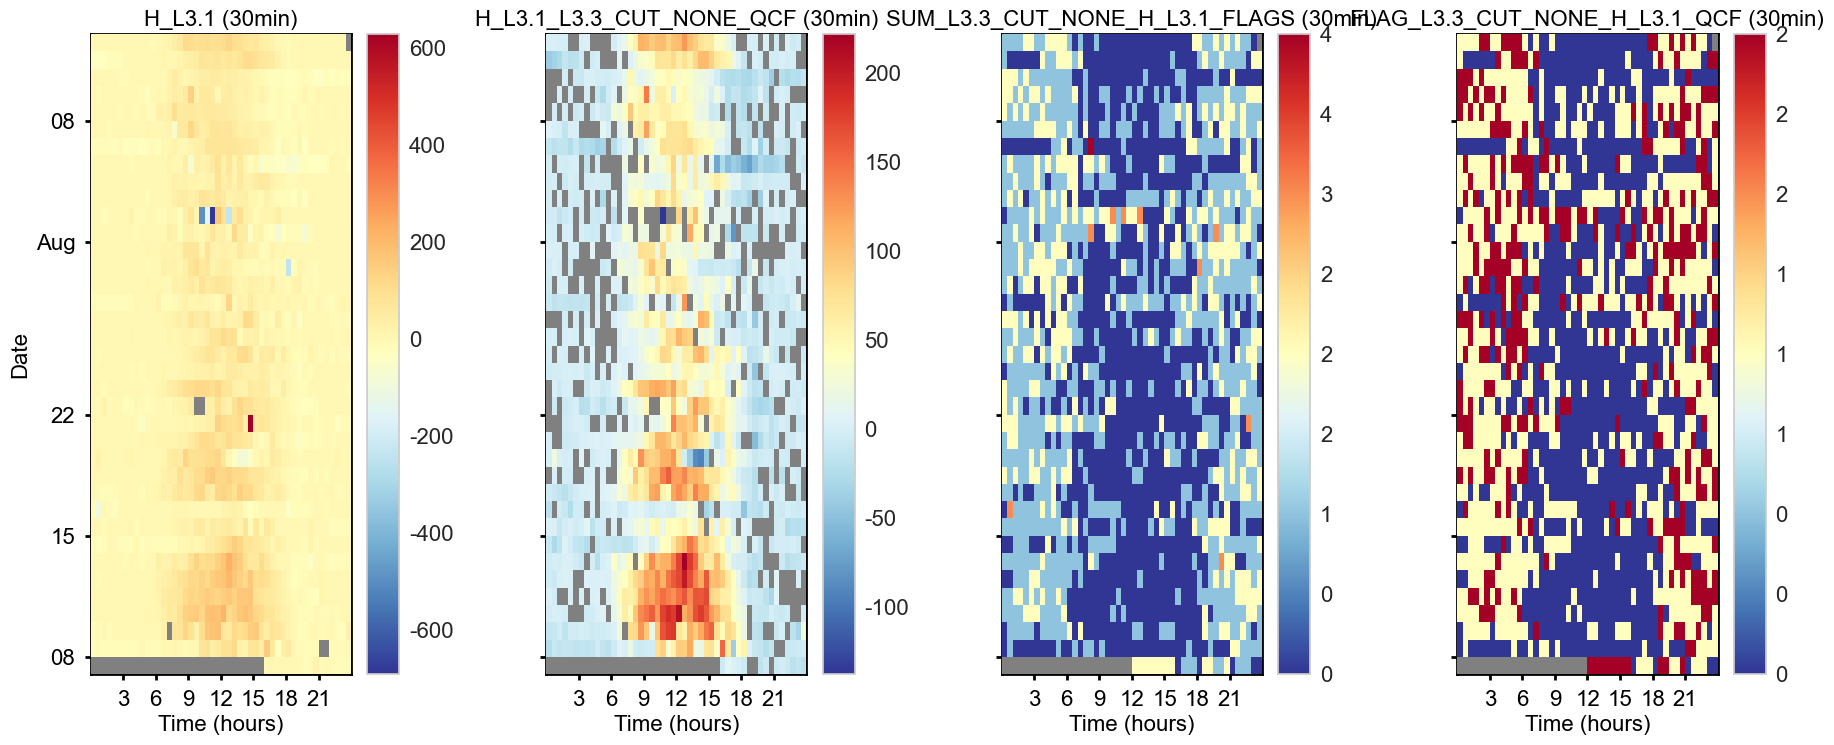

In [4]:
FLUXVARS = ['H']
SOURCEDIRS = [r"F:\Sync\luhk_work\TMP\CHA_rECord_IRGA72"]  # Folders where the EddyPro output files are located
irga72 = QuickFluxProcessingChain(
    fluxvars=FLUXVARS,
    sourcedirs=SOURCEDIRS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=UTC_OFFSET,
    nighttime_threshold=NIGHTTIME_THRESHOLD,
    daytime_accept_qcf_below=DAYTIME_ACCEPT_QCF_BELOW,
    nighttimetime_accept_qcf_below=NIGHTTIMETIME_ACCEPT_QCF_BELOW,
    test_signal_strength=False,
    test_signal_strength_col='CUSTOM_SIGNAL_STRENGTH_IRGA72_MEAN',
    test_signal_strength_method='discard below',
    test_signal_strength_threshold=60
)
res_irga72_df =  irga72.fpc.fpc_df
display(res_irga72_df.head())

## IRGA75

Found 41 files with extension *.csv and file IDs ['eddypro_', '_fluxnet_']:
 Found file #1: F:\Sync\luhk_work\TMP\CHA_sonicread_IRGA75\eddypro_CH-CHA_FR-20250701-081003_fluxnet_2025-07-01T081025_adv.csv
 Found file #2: F:\Sync\luhk_work\TMP\CHA_sonicread_IRGA75\eddypro_CH-CHA_FR-20250702-081003_fluxnet_2025-07-02T081028_adv.csv
 Found file #3: F:\Sync\luhk_work\TMP\CHA_sonicread_IRGA75\eddypro_CH-CHA_FR-20250704-081004_fluxnet_2025-07-04T081024_adv.csv
 Found file #4: F:\Sync\luhk_work\TMP\CHA_sonicread_IRGA75\eddypro_CH-CHA_FR-20250705-081003_fluxnet_2025-07-05T081022_adv.csv
 Found file #5: F:\Sync\luhk_work\TMP\CHA_sonicread_IRGA75\eddypro_CH-CHA_FR-20250706-081003_fluxnet_2025-07-06T081023_adv.csv
 Found file #6: F:\Sync\luhk_work\TMP\CHA_sonicread_IRGA75\eddypro_CH-CHA_FR-20250707-081003_fluxnet_2025-07-07T081022_adv.csv
 Found file #7: F:\Sync\luhk_work\TMP\CHA_sonicread_IRGA75\eddypro_CH-CHA_FR-20250708-081003_fluxnet_2025-07-08T081023_adv.csv
 Found file #8: F:\Sync\luhk_work\T

,H,USTAR,SW_IN_POT,DAYTIME,NIGHTTIME,FLAG_L2_H_MISSING_TEST,...,SUM_L3.3_CUT_NONE_H_L3.1_HARDFLAGS,SUM_L3.3_CUT_NONE_H_L3.1_SOFTFLAGS,SUM_L3.3_CUT_NONE_H_L3.1_FLAGS,FLAG_L3.3_CUT_NONE_H_L3.1_QCF,H_L3.1_L3.3_CUT_NONE_QCF,H_L3.1_L3.3_CUT_NONE_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2025-06-28 01:15:00,3.543550,0.047807,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,3.536024,NaN
2025-06-28 01:45:00,0.020359,0.099177,0.0,0.0,1.0,0.0,...,2.0,0.0,2.0,2.0,NaN,NaN
2025-06-28 02:15:00,0.733996,0.052685,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,0.726470,NaN
2025-06-28 02:45:00,0.396980,0.043042,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,0.513374,NaN
2025-06-28 03:15:00,-0.508766,0.030894,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,-0.107187,NaN


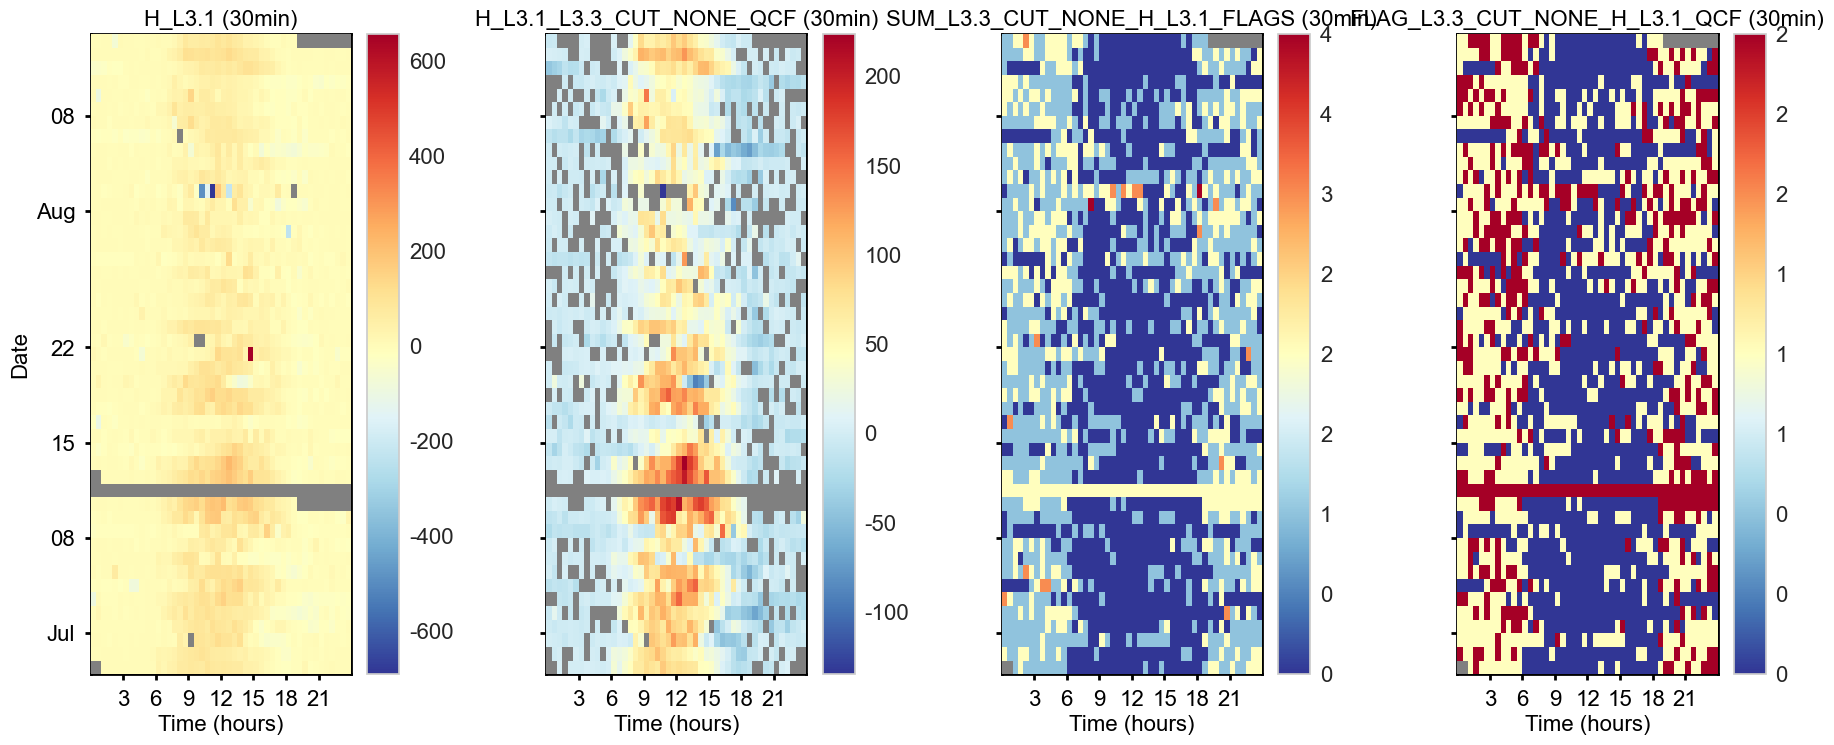

In [5]:
FLUXVARS = ['H']
SOURCEDIRS = [r"F:\Sync\luhk_work\TMP\CHA_sonicread_IRGA75"]  # Folders where the EddyPro output files are located
irga75 = QuickFluxProcessingChain(
    fluxvars=FLUXVARS,
    sourcedirs=SOURCEDIRS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=UTC_OFFSET,
    nighttime_threshold=NIGHTTIME_THRESHOLD,
    daytime_accept_qcf_below=DAYTIME_ACCEPT_QCF_BELOW,
    nighttimetime_accept_qcf_below=NIGHTTIMETIME_ACCEPT_QCF_BELOW,
    test_signal_strength=False,
    test_signal_strength_col='CUSTOM_AGC_MEAN',
    test_signal_strength_method='discard above',
    test_signal_strength_threshold=90
)
res_irga75_df =  irga75.fpc.fpc_df
display(res_irga75_df.head())

</br>

In [6]:
[print(c) for c in res_irga72_df.columns if "H" in c];

H
NIGHTTIME
FLAG_L2_H_MISSING_TEST
FLAG_L2_H_SSITC_TEST
FLAG_L2_H_COMPLETENESS_TEST
FLAG_L2_H_SCF_TEST
FLAG_L2_H_T_SONIC_VM97_SPIKE_HF_TEST
FLAG_L2_H_T_SONIC_VM97_DROPOUT_TEST
SUM_L2_H_HARDFLAGS
SUM_L2_H_SOFTFLAGS
SUM_L2_H_FLAGS
FLAG_L2_H_QCF
H_L2_QCF
H_L2_QCF0
SH_SINGLE
SH_SINGLE_gfRMED_L3.1
FLAG_SH_SINGLE_gfRMED_L3.1_ISFILLED
H_L3.1
H_L3.1_QCF
H_L3.1_QCF0
FLAG_L3.2_H_L3.1_QCF_OUTLIER_ZSCOREDTNT_TEST
SUM_L3.2_H_L3.1_HARDFLAGS
SUM_L3.2_H_L3.1_SOFTFLAGS
SUM_L3.2_H_L3.1_FLAGS
FLAG_L3.2_H_L3.1_QCF
H_L3.1_L3.2_QCF
H_L3.1_L3.2_QCF0
FLAG_L3.3_CUT_NONE_H_L3.1_USTAR_TEST
SUM_L3.3_CUT_NONE_H_L3.1_HARDFLAGS
SUM_L3.3_CUT_NONE_H_L3.1_SOFTFLAGS
SUM_L3.3_CUT_NONE_H_L3.1_FLAGS
FLAG_L3.3_CUT_NONE_H_L3.1_QCF
H_L3.1_L3.3_CUT_NONE_QCF
H_L3.1_L3.3_CUT_NONE_QCF0


In [7]:
[print(c) for c in res_irga75_df.columns if "H" in c];

H
NIGHTTIME
FLAG_L2_H_MISSING_TEST
FLAG_L2_H_SSITC_TEST
FLAG_L2_H_COMPLETENESS_TEST
FLAG_L2_H_SCF_TEST
FLAG_L2_H_T_SONIC_VM97_SPIKE_HF_TEST
FLAG_L2_H_T_SONIC_VM97_DROPOUT_TEST
SUM_L2_H_HARDFLAGS
SUM_L2_H_SOFTFLAGS
SUM_L2_H_FLAGS
FLAG_L2_H_QCF
H_L2_QCF
H_L2_QCF0
SH_SINGLE
SH_SINGLE_gfRMED_L3.1
FLAG_SH_SINGLE_gfRMED_L3.1_ISFILLED
H_L3.1
H_L3.1_QCF
H_L3.1_QCF0
FLAG_L3.2_H_L3.1_QCF_OUTLIER_ZSCOREDTNT_TEST
SUM_L3.2_H_L3.1_HARDFLAGS
SUM_L3.2_H_L3.1_SOFTFLAGS
SUM_L3.2_H_L3.1_FLAGS
FLAG_L3.2_H_L3.1_QCF
H_L3.1_L3.2_QCF
H_L3.1_L3.2_QCF0
FLAG_L3.3_CUT_NONE_H_L3.1_USTAR_TEST
SUM_L3.3_CUT_NONE_H_L3.1_HARDFLAGS
SUM_L3.3_CUT_NONE_H_L3.1_SOFTFLAGS
SUM_L3.3_CUT_NONE_H_L3.1_FLAGS
FLAG_L3.3_CUT_NONE_H_L3.1_QCF
H_L3.1_L3.3_CUT_NONE_QCF
H_L3.1_L3.3_CUT_NONE_QCF0


## QCF0+1

Number of records: 1365
Cumulative sums:
H_L3.1_L3.3_CUT_NONE_QCF_IRGA72    30024.157225
H_L3.1_L3.3_CUT_NONE_QCF_IRGA75    29102.228003
Name: 2025-08-12 23:15:00, dtype: float64
103.16789911034643


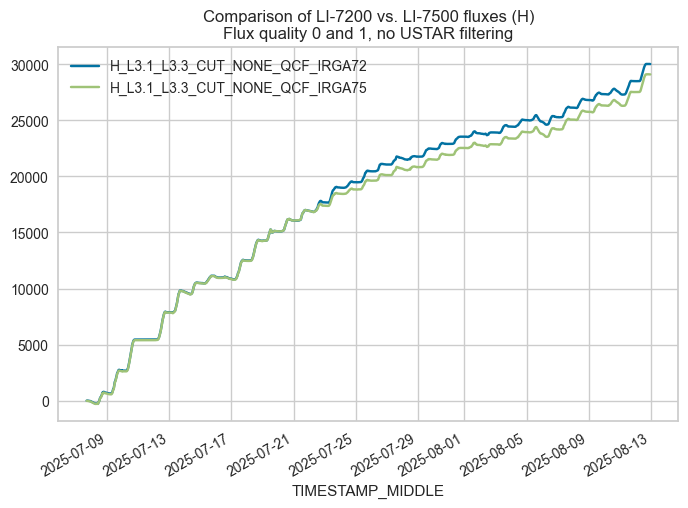

In [10]:
h = pd.DataFrame()
h['H_L3.1_L3.3_CUT_NONE_QCF_IRGA72'] = res_irga72_df['H_L3.1_L3.3_CUT_NONE_QCF']
h['H_L3.1_L3.3_CUT_NONE_QCF_IRGA75'] = res_irga75_df['H_L3.1_L3.3_CUT_NONE_QCF']
h = h.dropna()
print(f"Number of records: {len(h)}")
h_cumsum = h.cumsum()
h_cumsum.plot(title="Comparison of LI-7200 vs. LI-7500 fluxes (H)\nFlux quality 0 and 1, no USTAR filtering");
print("Cumulative sums:")
print(h_cumsum.iloc[-1])
perc = (h_cumsum.iloc[-1]['H_L3.1_L3.3_CUT_NONE_QCF_IRGA72'] / h_cumsum.iloc[-1]['H_L3.1_L3.3_CUT_NONE_QCF_IRGA75']) * 100
print(perc)

## QCF0

Number of records: 715
Cumulative sums:
H_L3.1_L3.3_CUT_NONE_QCF_IRGA72    26328.633386
H_L3.1_L3.3_CUT_NONE_QCF_IRGA75    25525.922838
Name: 2025-08-12 23:15:00, dtype: float64
103.14468767141153


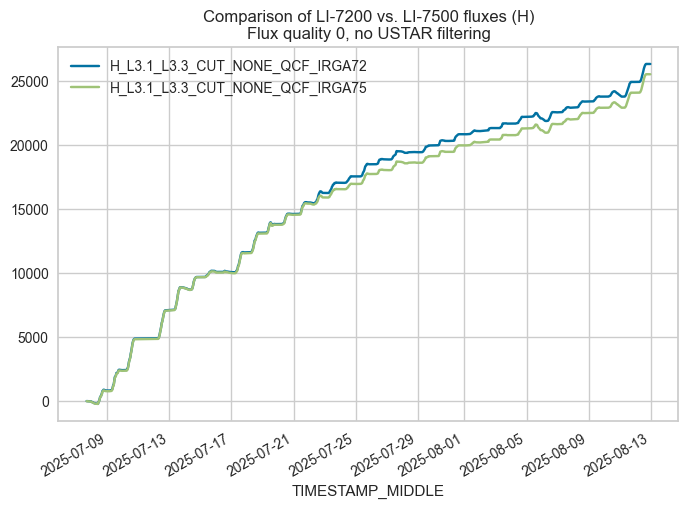

In [12]:
h = pd.DataFrame()
h['H_L3.1_L3.3_CUT_NONE_QCF_IRGA72'] = res_irga72_df['H_L3.1_L3.3_CUT_NONE_QCF0']
h['H_L3.1_L3.3_CUT_NONE_QCF_IRGA75'] = res_irga75_df['H_L3.1_L3.3_CUT_NONE_QCF0']
h = h.dropna()
print(f"Number of records: {len(h)}")
h_cumsum = h.cumsum()
h_cumsum.plot(title="Comparison of LI-7200 vs. LI-7500 fluxes (H)\nFlux quality 0, no USTAR filtering");
print("Cumulative sums:")
print(h_cumsum.iloc[-1])
perc = (h_cumsum.iloc[-1]['H_L3.1_L3.3_CUT_NONE_QCF_IRGA72'] / h_cumsum.iloc[-1]['H_L3.1_L3.3_CUT_NONE_QCF_IRGA75']) * 100
print(perc)

</br>

# **End of notebook**
Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")